## 1. Імпорт необхідних бібліотек

In [1]:
# Основні бібліотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Обробка тексту
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Word2Vec
from gensim.models import Word2Vec

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Моделі класифікації
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Метрики
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix

# Завантаження NLTK ресурсів
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Бібліотеки успішно завантажені!")

Бібліотеки успішно завантажені!


## 2. Завантаження та огляд даних

In [2]:
# Завантаження датасету
df = pd.read_csv('covid_tweets.csv', encoding='latin-1')

print(f"Розмір датасету: {df.shape}")
print(f"\nПерші 5 рядків:")
df.head()

Розмір датасету: (3798, 6)

Перші 5 рядків:


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [3]:
# Інформація про датасет
print("Інформація про датасет:")
df.info()

print("\nПропущені значення:")
print(df.isnull().sum())

print("\nРозподіл класів:")
print(df['Sentiment'].value_counts())

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB

Пропущені значення:
UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64

Розподіл класів:
Sentiment
Negative              1041
Positive               947
Neutral                619
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64


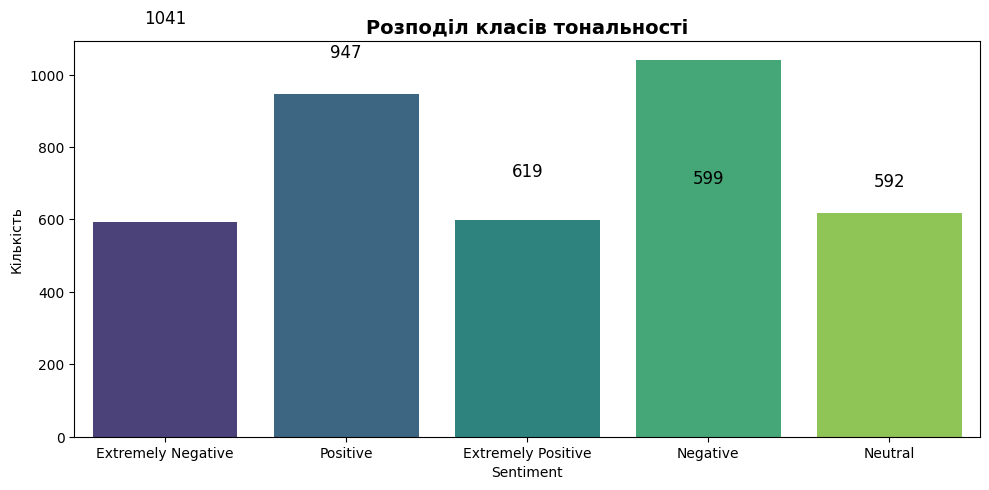

In [4]:
# Візуалізація розподілу класів
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Sentiment', palette='viridis')
plt.title('Розподіл класів тональності', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Кількість')
plt.xticks(rotation=0)
for i, count in enumerate(df['Sentiment'].value_counts()):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Попередня обробка тексту

In [5]:
# Функція для очистки тексту
def clean_text(text):
    """
    Очищає текст від спеціальних символів, URLs, згадок, хештегів
    Приводить до нижнього регістру
    """
    if pd.isna(text):
        return ""
    
    # Приведення до нижнього регістру
    text = text.lower()
    
    # Видалення URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Видалення згадок (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Видалення хештегів (#hashtag)
    text = re.sub(r'#\w+', '', text)
    
    # Видалення цифр
    text = re.sub(r'\d+', '', text)
    
    # Видалення пунктуації та спеціальних символів
    text = re.sub(r'[^\w\s]', '', text)
    
    # Видалення зайвих пробілів
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Застосування очистки до всіх твітів
df['cleaned_tweet'] = df['OriginalTweet'].apply(clean_text)

print("Приклади очищених твітів:")
for i in range(3):
    print(f"\nОригінал: {df['OriginalTweet'].iloc[i][:100]}...")
    print(f"Очищений: {df['cleaned_tweet'].iloc[i][:100]}...")

Приклади очищених твітів:

Оригінал: TRENDING: New Yorkers encounter empty supermarket shelves (pictured, Wegmans in Brooklyn), sold-out ...
Очищений: trending new yorkers encounter empty supermarket shelves pictured wegmans in brooklyn soldout online...

Оригінал: When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack of ...
Очищений: when i couldnt find hand sanitizer at fred meyer i turned to but for a pack of purellcheck out how c...

Оригінал: Find out how you can protect yourself and loved ones from #coronavirus. ?...
Очищений: find out how you can protect yourself and loved ones from...


In [6]:
# Токенізація та видалення стоп-слів
stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    """
    Токенізує текст та видаляє стоп-слова
    """
    if not text:
        return []
    
    # Токенізація
    tokens = word_tokenize(text)
    
    # Видалення стоп-слів та коротких слів (менше 2 символів)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return tokens

# Застосування токенізації
df['tokens'] = df['cleaned_tweet'].apply(tokenize_and_remove_stopwords)

# Видалення порожніх твітів
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)

print(f"Розмір датасету після очистки: {df.shape}")
print(f"\nПриклади токенізованих твітів:")
for i in range(3):
    print(f"\nТвіт {i+1}: {df['tokens'].iloc[i][:10]}...")

Розмір датасету після очистки: (3795, 8)

Приклади токенізованих твітів:

Твіт 1: ['trending', 'new', 'yorkers', 'encounter', 'empty', 'supermarket', 'shelves', 'pictured', 'wegmans', 'brooklyn']...

Твіт 2: ['couldnt', 'find', 'hand', 'sanitizer', 'fred', 'meyer', 'turned', 'pack', 'purellcheck', 'concerns']...

Твіт 3: ['find', 'protect', 'loved', 'ones']...


## 4. Навчання Word2Vec моделі

In [7]:
# Параметри Word2Vec
VECTOR_SIZE = 100  # Розмірність векторів
WINDOW = 5         # Розмір вікна контексту
MIN_COUNT = 2      # Мінімальна частота слова
WORKERS = 4        # Кількість потоків
SG = 0             # 0 = CBOW, 1 = Skip-gram

# Навчання Word2Vec моделі
print("Навчання Word2Vec моделі...")
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=SG,
    epochs=10
)

print(f"\nWord2Vec модель навчена!")
print(f"Розмір словника: {len(w2v_model.wv)}")
print(f"Розмірність векторів: {w2v_model.wv.vector_size}")

Навчання Word2Vec моделі...

Word2Vec модель навчена!
Розмір словника: 4492
Розмірність векторів: 100

Word2Vec модель навчена!
Розмір словника: 4492
Розмірність векторів: 100


In [8]:
# Перевірка подібності слів
test_words = ['covid', 'virus', 'vaccine', 'pandemic', 'health']

print("Приклади найбільш подібних слів:")
for word in test_words:
    if word in w2v_model.wv:
        similar_words = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}': {[w[0] for w in similar_words]}")
    else:
        print(f"\n'{word}': не знайдено у словнику")

Приклади найбільш подібних слів:

'covid': ['due', 'demand', 'increased', 'help', 'increase']

'virus': ['hope', 'fear', 'must', 'protect', 'sell']

'vaccine': ['actually', 'shops', 'says', 'related', 'mass']

'pandemic': ['situation', 'govt', 'made', 'crisis', 'low']

'health': ['global', 'impact', 'coronavirus', 'high', 'issues']


## 5. Створення векторних представлень твітів

In [24]:
def tweet_to_vector(tokens, model):
    """
    Перетворює твіт (список токенів) у вектор шляхом конкатенації:
    - mean (середнє значення векторів)
    - max (максимальні значення по кожній розмірності)
    - min (мінімальні значення по кожній розмірності)
    
    Це дає більш багаті ознаки порівняно з простим усередненням.
    """
    # Отримуємо вектори для слів, що є у словнику
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if len(vectors) == 0:
        # Якщо жодне слово не знайдено, повертаємо нульовий вектор (розмірності x3)
        return np.zeros(model.wv.vector_size * 3)
    
    vectors_array = np.array(vectors)
    
    # Обчислюємо статистики
    mean_vec = np.mean(vectors_array, axis=0)
    max_vec = np.max(vectors_array, axis=0)
    min_vec = np.min(vectors_array, axis=0)
    
    # Конкатенуємо всі три вектори
    return np.concatenate([mean_vec, max_vec, min_vec])

# Створення векторів для всіх твітів
print("Створення векторних представлень твітів (mean+max+min)...")
X = np.array([tweet_to_vector(tokens, w2v_model) for tokens in df['tokens']])

print(f"Розмір матриці ознак: {X.shape}")
print(f"Розмірність одного вектору: {X.shape[1]} (100 x 3 статистики)")
print(f"Приклад вектору (перші 10 елементів): {X[0][:10]}")


Створення векторних представлень твітів (mean+max+min)...
Розмір матриці ознак: (3795, 300)
Розмірність одного вектору: 300 (100 x 3 статистики)
Приклад вектору (перші 10 елементів): [-0.07536723  0.39470282  0.13808405 -0.08371633  0.10334675 -0.49498171
  0.0921947   0.70600212 -0.26330814 -0.33348632]


In [25]:
# Кодування цільової змінної
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Sentiment'])

print(f"Класи: {label_encoder.classes_}")
print(f"Кодування: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"\nРозподіл закодованих класів:")
unique, counts = np.unique(y, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {label_encoder.inverse_transform([cls])[0]}: {count}")

Класи: ['Extremely Negative' 'Extremely Positive' 'Negative' 'Neutral' 'Positive']
Кодування: {'Extremely Negative': np.int64(0), 'Extremely Positive': np.int64(1), 'Negative': np.int64(2), 'Neutral': np.int64(3), 'Positive': np.int64(4)}

Розподіл закодованих класів:
  Extremely Negative: 592
  Extremely Positive: 599
  Negative: 1041
  Neutral: 616
  Positive: 947


## 6. Розділення на тренувальну та тестову вибірки

In [26]:
# Розділення даних (80% тренувальна, 20% тестова)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")
print(f"\nРозподіл класів у тренувальній вибірці:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  {label_encoder.inverse_transform([cls])[0]}: {count}")

Розмір тренувальної вибірки: (3036, 300)
Розмір тестової вибірки: (759, 300)

Розподіл класів у тренувальній вибірці:
  Extremely Negative: 473
  Extremely Positive: 479
  Negative: 833
  Neutral: 493
  Positive: 758


## 7. Побудова та оцінка моделей без PCA

In [27]:
# Словник з моделями (з class_weight="balanced" для кращої роботи з дисбалансом)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB()
}

# Словник для зберігання результатів
results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, pca_components=None):
    """
    Навчає модель та обчислює метрики
    """
    # Навчання моделі
    model.fit(X_train, y_train)
    
    # Прогнозування
    y_pred = model.predict(X_test)
    
    # Обчислення метрик
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    
    result = {
        'Model': model_name,
        'PCA Components': pca_components if pca_components else 'None',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    return result, y_pred

print("Навчання моделей без PCA...\n")
print("Примітка: Використовується class_weight='balanced' для компенсації дисбалансу класів\n")

# Навчання та оцінка моделей
predictions_no_pca = {}
for name, model in models.items():
    print(f"Навчання {name}...")
    result, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    results.append(result)
    predictions_no_pca[name] = y_pred
    print(f"  Accuracy: {result['Accuracy']:.4f}")

print("\nНавчання без PCA завершено!")


Навчання моделей без PCA...

Примітка: Використовується class_weight='balanced' для компенсації дисбалансу класів

Навчання Logistic Regression...
  Accuracy: 0.3070
Навчання SVM...
  Accuracy: 0.3070
Навчання SVM...
  Accuracy: 0.2582
Навчання Random Forest...
  Accuracy: 0.2582
Навчання Random Forest...
  Accuracy: 0.3426
Навчання Naive Bayes...
  Accuracy: 0.2240

Навчання без PCA завершено!
  Accuracy: 0.3426
Навчання Naive Bayes...
  Accuracy: 0.2240

Навчання без PCA завершено!


In [13]:
# Детальний звіт для кожної моделі (без PCA)
print("\n" + "="*80)
print("ДЕТАЛЬНІ ЗВІТИ ДЛЯ МОДЕЛЕЙ БЕЗ PCA")
print("="*80)

for name, y_pred in predictions_no_pca.items():
    print(f"\n{name}:")
    print("-" * 60)
    print(classification_report(
        y_test, y_pred, 
        target_names=label_encoder.classes_,
        zero_division=0
    ))


ДЕТАЛЬНІ ЗВІТИ ДЛЯ МОДЕЛЕЙ БЕЗ PCA

Logistic Regression:
------------------------------------------------------------
                    precision    recall  f1-score   support

Extremely Negative       0.00      0.00      0.00       119
Extremely Positive       0.00      0.00      0.00       120
          Negative       0.30      0.76      0.43       208
           Neutral       0.52      0.10      0.16       123
          Positive       0.35      0.40      0.37       189

          accuracy                           0.32       759
         macro avg       0.24      0.25      0.19       759
      weighted avg       0.26      0.32      0.24       759


SVM:
------------------------------------------------------------
                    precision    recall  f1-score   support

Extremely Negative       0.00      0.00      0.00       119
Extremely Positive       0.00      0.00      0.00       120
          Negative       0.28      0.99      0.43       208
           Neutral       0.67 

## 8. Експеримент з PCA

In [28]:
# Кількість компонент для PCA
pca_components_list = [50, 100]

print("Експеримент з PCA...\n")

# Навчання моделей з різною кількістю PCA компонент
for n_components in pca_components_list:
    print(f"\nPCA з {n_components} компонентами:")
    print("-" * 60)
    
    # Застосування PCA
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    explained_variance = pca.explained_variance_ratio_.sum()
    print(f"Пояснена дисперсія: {explained_variance:.4f}\n")
    
    # Навчання моделей
    for name, model_class in models.items():
        # Створюємо нову модель для кожного експерименту
        if name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, random_state=42)
        elif name == 'SVM':
            model = SVC(kernel='rbf', random_state=42)
        elif name == 'Random Forest':
            model = RandomForestClassifier(n_estimators=100, random_state=42)
        else:
            model = GaussianNB()
        
        result, _ = evaluate_model(
            model, X_train_pca, X_test_pca, y_train, y_test, name, n_components
        )
        results.append(result)
        print(f"  {name}: Accuracy = {result['Accuracy']:.4f}")

print("\nЕксперимент з PCA завершено!")

Експеримент з PCA...


PCA з 50 компонентами:
------------------------------------------------------------
Пояснена дисперсія: 0.9944

  Logistic Regression: Accuracy = 0.3136
  SVM: Accuracy = 0.3267
  SVM: Accuracy = 0.3267
  Random Forest: Accuracy = 0.3307
  Naive Bayes: Accuracy = 0.2754

PCA з 100 компонентами:
------------------------------------------------------------
Пояснена дисперсія: 0.9982

  Logistic Regression: Accuracy = 0.3175
  Random Forest: Accuracy = 0.3307
  Naive Bayes: Accuracy = 0.2754

PCA з 100 компонентами:
------------------------------------------------------------
Пояснена дисперсія: 0.9982

  Logistic Regression: Accuracy = 0.3175
  SVM: Accuracy = 0.3202
  SVM: Accuracy = 0.3202
  Random Forest: Accuracy = 0.3281
  Naive Bayes: Accuracy = 0.2556

Експеримент з PCA завершено!
  Random Forest: Accuracy = 0.3281
  Naive Bayes: Accuracy = 0.2556

Експеримент з PCA завершено!


## 9. Порівняння результатів

In [29]:
# Створення DataFrame з результатами
results_df = pd.DataFrame(results)

# Форматування для кращого відображення
results_df_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    results_df_display[col] = results_df_display[col].apply(lambda x: f"{x:.4f}")

print("\n" + "="*100)
print("ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ")
print("="*100)
print(results_df_display.to_string(index=False))
print("="*100)


ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ
              Model PCA Components Accuracy Precision Recall F1-Score
Logistic Regression           None   0.3070    0.2949 0.3070   0.2780
                SVM           None   0.2582    0.2901 0.2582   0.2197
      Random Forest           None   0.3426    0.3506 0.3426   0.3377
        Naive Bayes           None   0.2240    0.2935 0.2240   0.1799
Logistic Regression             50   0.3136    0.3324 0.3136   0.2916
                SVM             50   0.3267    0.2421 0.3267   0.2556
      Random Forest             50   0.3307    0.3389 0.3307   0.3221
        Naive Bayes             50   0.2754    0.2924 0.2754   0.2715
Logistic Regression            100   0.3175    0.3247 0.3175   0.2949
                SVM            100   0.3202    0.2365 0.3202   0.2503
      Random Forest            100   0.3281    0.3492 0.3281   0.3157
        Naive Bayes            100   0.2556    0.2717 0.2556   0.2512


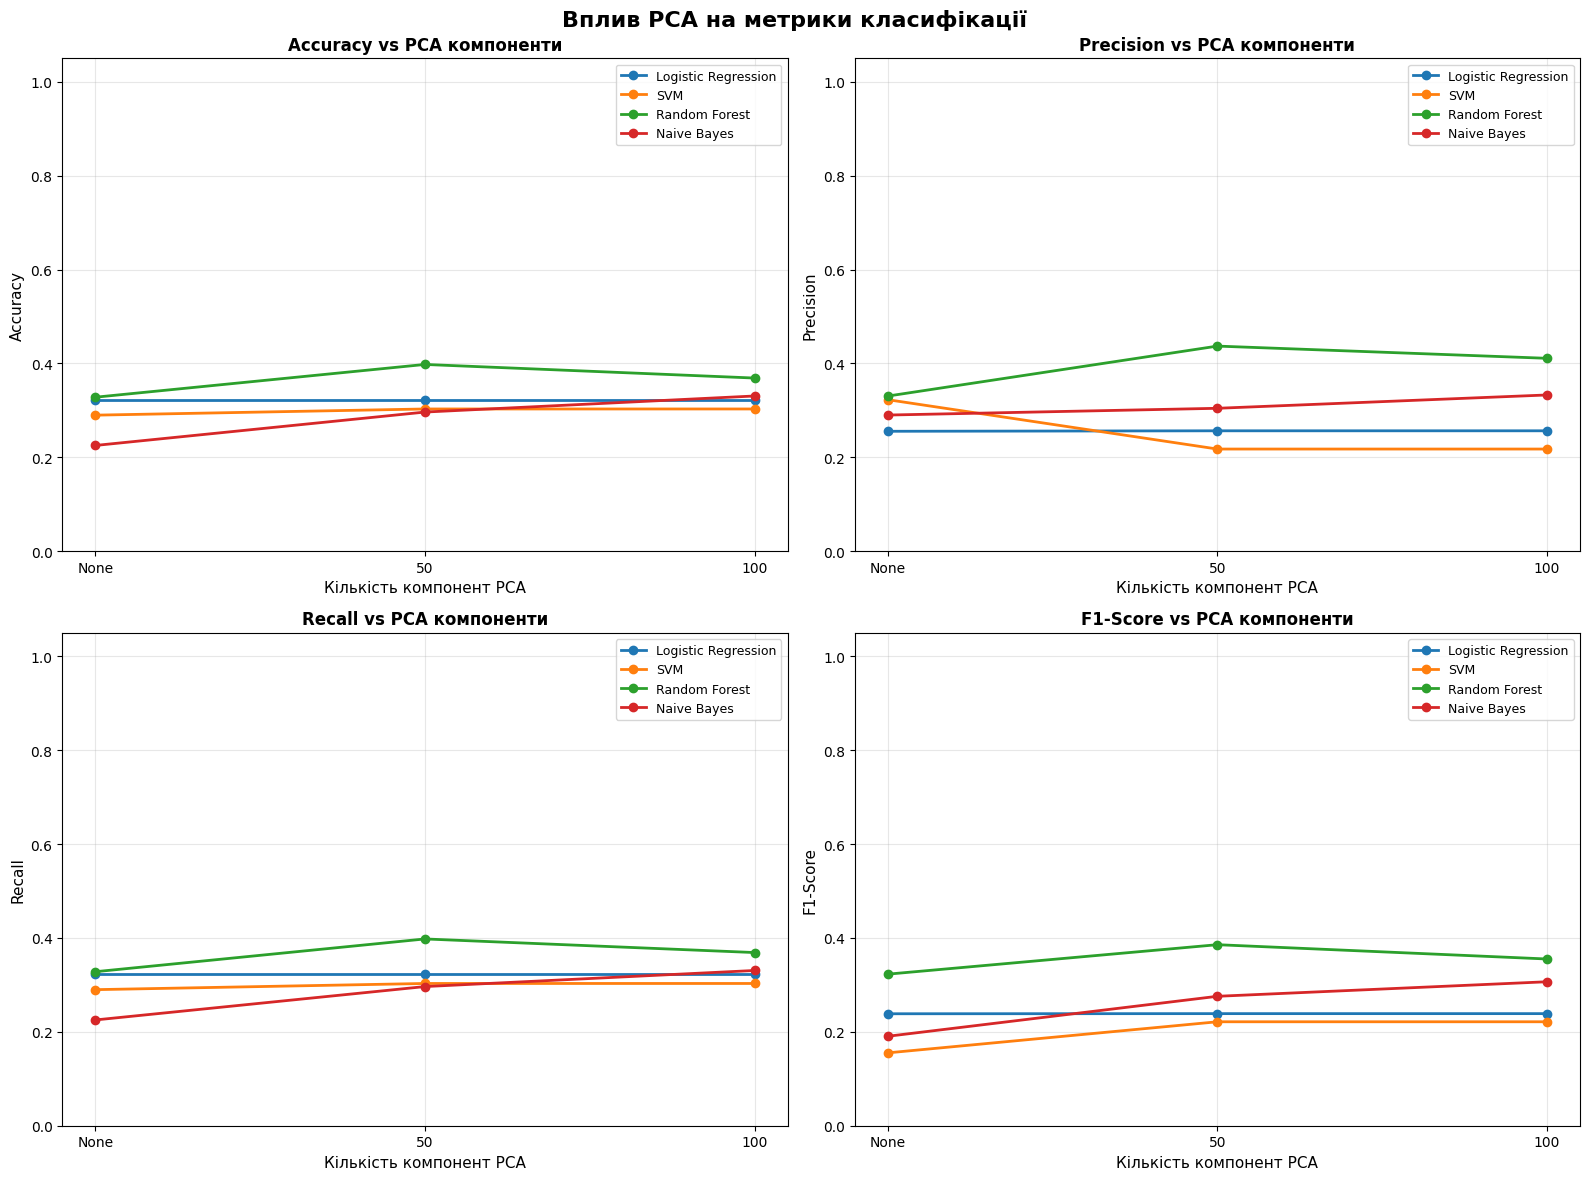

In [16]:
# Візуалізація впливу PCA на точність
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Вплив PCA на метрики класифікації', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Підготовка даних для графіка
    for model_name in models.keys():
        model_data = results_df[results_df['Model'] == model_name]
        
        # Отримуємо значення для різних конфігурацій PCA
        pca_labels = model_data['PCA Components'].tolist()
        metric_values = model_data[metric].tolist()
        
        ax.plot(pca_labels, metric_values, marker='o', linewidth=2, label=model_name)
    
    ax.set_xlabel('Кількість компонент PCA', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} vs PCA компоненти', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

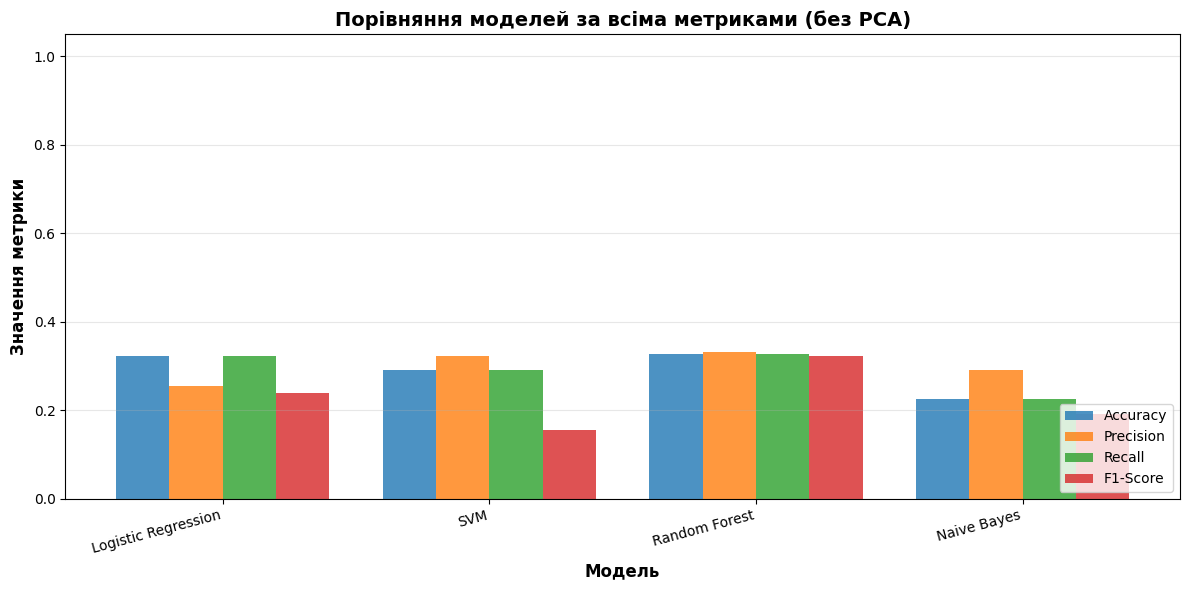

In [17]:
# Порівняння моделей за всіма метриками (без PCA)
fig, ax = plt.subplots(figsize=(12, 6))

# Отримуємо результати без PCA
no_pca_results = results_df[results_df['PCA Components'] == 'None']

x = np.arange(len(models))
width = 0.2

metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics_plot):
    values = no_pca_results[metric].values
    ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8)

ax.set_xlabel('Модель', fontsize=12, fontweight='bold')
ax.set_ylabel('Значення метрики', fontsize=12, fontweight='bold')
ax.set_title('Порівняння моделей за всіма метриками (без PCA)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models.keys(), rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 10. Confusion Matrix для найкращої моделі

Найкраща модель: Random Forest
Accuracy: 0.3426


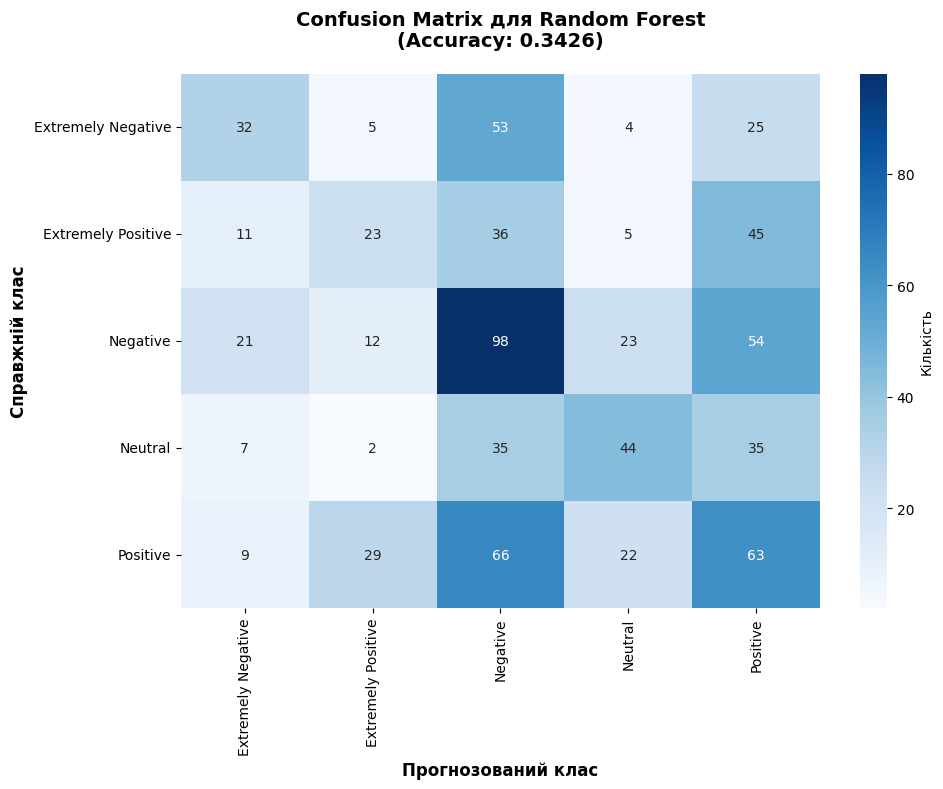

In [30]:
# Знаходимо найкращу модель (без PCA)
best_model_row = results_df[results_df['PCA Components'] == 'None'].sort_values('Accuracy', ascending=False).iloc[0]
best_model_name = best_model_row['Model']
best_accuracy = best_model_row['Accuracy']

print(f"Найкраща модель: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")

# Отримуємо прогнози найкращої моделі
y_pred_best = predictions_no_pca[best_model_name]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Візуалізація
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Кількість'})
plt.title(f'Confusion Matrix для {best_model_name}\n(Accuracy: {best_accuracy:.4f})', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Справжній клас', fontsize=12, fontweight='bold')
plt.xlabel('Прогнозований клас', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

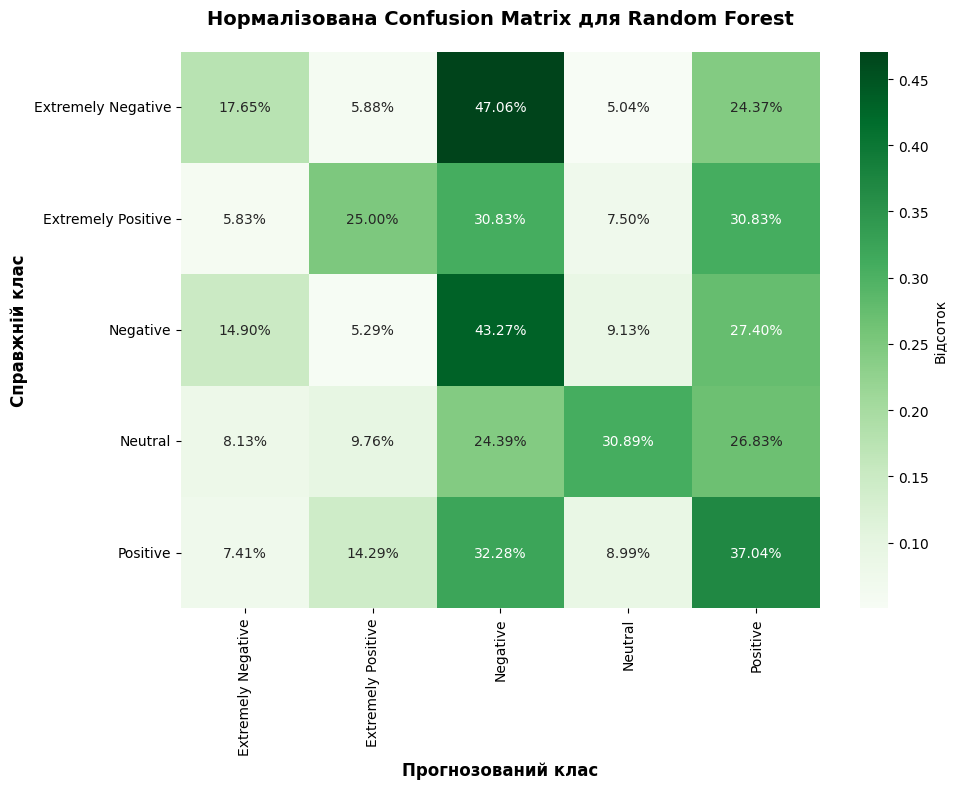

In [19]:
# Нормалізована Confusion Matrix (у відсотках)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Відсоток'})
plt.title(f'Нормалізована Confusion Matrix для {best_model_name}', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Справжній клас', fontsize=12, fontweight='bold')
plt.xlabel('Прогнозований клас', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Пояснена дисперсія PCA

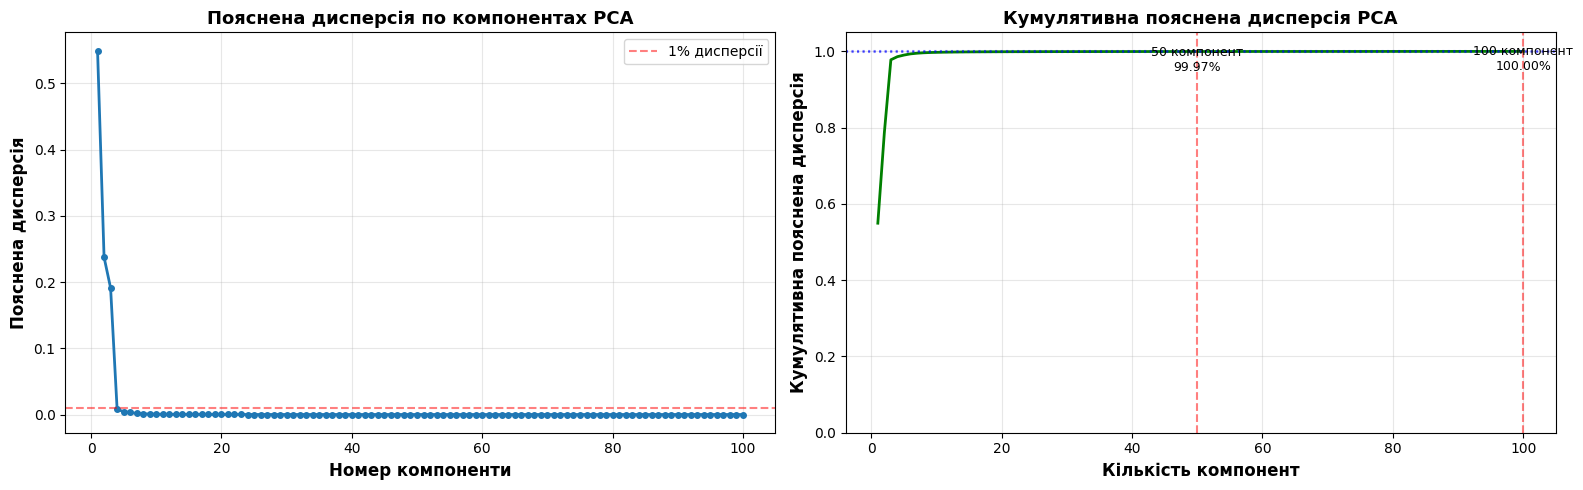


Пояснена дисперсія при різній кількості компонент:
  50 компонент: 99.97%
  100 компонент: 100.00%


In [20]:
# Аналіз поясненої дисперсії для різної кількості компонент
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

# Кумулятивна пояснена дисперсія
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Графік 1: Пояснена дисперсія по компонентах
ax1.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, marker='o', linewidth=2, markersize=4)
ax1.axhline(y=0.01, color='r', linestyle='--', alpha=0.5, label='1% дисперсії')
ax1.set_xlabel('Номер компоненти', fontsize=12, fontweight='bold')
ax1.set_ylabel('Пояснена дисперсія', fontsize=12, fontweight='bold')
ax1.set_title('Пояснена дисперсія по компонентах PCA', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Графік 2: Кумулятивна пояснена дисперсія
ax2.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 
         linewidth=2, color='green')
for n in [50, 100]:
    if n <= len(cumsum_variance):
        ax2.axvline(x=n, color='red', linestyle='--', alpha=0.5)
        ax2.axhline(y=cumsum_variance[n-1], color='blue', linestyle=':', alpha=0.5)
        ax2.text(n, cumsum_variance[n-1] - 0.05, 
                f'{n} компонент\n{cumsum_variance[n-1]:.2%}', 
                fontsize=9, ha='center')

ax2.set_xlabel('Кількість компонент', fontsize=12, fontweight='bold')
ax2.set_ylabel('Кумулятивна пояснена дисперсія', fontsize=12, fontweight='bold')
ax2.set_title('Кумулятивна пояснена дисперсія PCA', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"\nПояснена дисперсія при різній кількості компонент:")
for n in [50, 100]:
    if n <= len(cumsum_variance):
        print(f"  {n} компонент: {cumsum_variance[n-1]:.2%}")

## 12. Приклад прогнозування нових твітів

In [31]:
# Функція для прогнозування тональності нового твіту
def predict_sentiment(tweet_text, model, w2v_model, label_encoder):
    """
    Прогнозує тональність нового твіту
    """
    # Очистка тексту
    cleaned = clean_text(tweet_text)
    
    # Токенізація
    tokens = tokenize_and_remove_stopwords(cleaned)
    
    if len(tokens) == 0:
        return "Недостатньо інформації для прогнозу", None
    
    # Створення вектору
    vector = tweet_to_vector(tokens, w2v_model).reshape(1, -1)
    
    # Прогнозування
    prediction = model.predict(vector)[0]
    sentiment = label_encoder.inverse_transform([prediction])[0]
    
    # Отримання ймовірностей (якщо модель підтримує)
    probabilities = None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vector)[0]
        probabilities = dict(zip(label_encoder.classes_, proba))
    
    return sentiment, probabilities

# Тренуємо найкращу модель на повних даних
if best_model_name == 'Logistic Regression':
    final_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
elif best_model_name == 'SVM':
    final_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
else:
    final_model = GaussianNB()

final_model.fit(X_train, y_train)

# Приклади твітів для тестування
test_tweets = [
    "I'm so grateful for the vaccine! Finally feeling safe again. #COVID19",
    "This pandemic has been absolutely devastating for our community. So many lives lost.",
    "Just got my booster shot today at the clinic.",
    "The government's response to COVID has been terrible and incompetent!",
    "Scientists are working hard to understand this virus better every day."
]

print("\n" + "="*80)
print("ПРОГНОЗУВАННЯ ТОНАЛЬНОСТІ НОВИХ ТВІТІВ")
print("="*80)
print(f"Модель: {best_model_name}\n")

for i, tweet in enumerate(test_tweets, 1):
    sentiment, probabilities = predict_sentiment(tweet, final_model, w2v_model, label_encoder)
    print(f"{i}. Твіт: {tweet}")
    print(f"   Прогноз: {sentiment}")
    
    # Показуємо ймовірності, якщо доступні
    if probabilities:
        print("   Ймовірності:")
        # Сортуємо за спаданням ймовірності
        sorted_probs = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)
        for cls, prob in sorted_probs:
            print(f"      {cls}: {prob:.4f} ({prob*100:.2f}%)")
    print()



ПРОГНОЗУВАННЯ ТОНАЛЬНОСТІ НОВИХ ТВІТІВ
Модель: Random Forest

1. Твіт: I'm so grateful for the vaccine! Finally feeling safe again. #COVID19
   Прогноз: Negative
   Ймовірності:
      Negative: 0.3400 (34.00%)
      Extremely Negative: 0.2700 (27.00%)
      Neutral: 0.1900 (19.00%)
      Positive: 0.1100 (11.00%)
      Extremely Positive: 0.0900 (9.00%)

2. Твіт: This pandemic has been absolutely devastating for our community. So many lives lost.
   Прогноз: Negative
   Ймовірності:
      Negative: 0.3500 (35.00%)
      Positive: 0.2600 (26.00%)
      Neutral: 0.2000 (20.00%)
      Extremely Negative: 0.1100 (11.00%)
      Extremely Positive: 0.0800 (8.00%)

3. Твіт: Just got my booster shot today at the clinic.
   Прогноз: Neutral
   Ймовірності:
      Neutral: 0.4000 (40.00%)
      Positive: 0.2600 (26.00%)
      Negative: 0.1900 (19.00%)
      Extremely Negative: 0.0900 (9.00%)
      Extremely Positive: 0.0600 (6.00%)

4. Твіт: The government's response to COVID has been terrible a

## 13. Висновки

In [32]:
print("\n" + "="*80)
print("ВИСНОВКИ")
print("="*80)

# 1. Найкраща модель
print("\n1. НАЙКРАЩА МОДЕЛЬ:")
print("-" * 80)
best_row = results_df.sort_values('Accuracy', ascending=False).iloc[0]
print(f"   Модель: {best_row['Model']}")
print(f"   PCA компоненти: {best_row['PCA Components']}")
print(f"   Accuracy: {best_row['Accuracy']:.4f}")
print(f"   F1-Score: {best_row['F1-Score']:.4f}")

# 2. Вплив PCA
print("\n2. ВПЛИВ PCA НА ЯКІСТЬ КЛАСИФІКАЦІЇ:")
print("-" * 80)
for model_name in models.keys():
    model_results = results_df[results_df['Model'] == model_name]
    no_pca = model_results[model_results['PCA Components'] == 'None']['Accuracy'].values[0]
    with_pca = model_results[model_results['PCA Components'] != 'None']['Accuracy'].max()
    diff = with_pca - no_pca
    
    print(f"\n   {model_name}:")
    print(f"      Без PCA: {no_pca:.4f}")
    print(f"      З PCA (найкраще): {with_pca:.4f}")
    print(f"      Різниця: {diff:+.4f} ({'+' if diff > 0 else ''}{diff/no_pca*100:.2f}%)")

# 3. Статистика по моделях
print("\n3. СТАТИСТИКА ПО МОДЕЛЯХ:")
print("-" * 80)
model_stats = results_df.groupby('Model')['Accuracy'].agg(['mean', 'max', 'min', 'std'])
model_stats = model_stats.sort_values('mean', ascending=False)
print("\nСередні показники Accuracy:")
for idx, row in model_stats.iterrows():
    print(f"   {idx}:")
    print(f"      Середнє: {row['mean']:.4f}")
    print(f"      Максимум: {row['max']:.4f}")
    print(f"      Мінімум: {row['min']:.4f}")
    print(f"      Станд. відхилення: {row['std']:.4f}")

# 4. Загальні висновки
print("\n4. ЗАГАЛЬНІ ВИСНОВКИ:")
print("-" * 80)

avg_no_pca = results_df[results_df['PCA Components'] == 'None']['Accuracy'].mean()
avg_with_pca = results_df[results_df['PCA Components'] != 'None']['Accuracy'].mean()

print(f"\n   • Середня точність без PCA: {avg_no_pca:.4f}")
print(f"   • Середня точність з PCA: {avg_with_pca:.4f}")
print(f"\n   • Word2Vec успішно створює векторні представлення твітів")
print(f"   • Розмірність векторів: {VECTOR_SIZE} x 3 статистики (mean, max, min) = {VECTOR_SIZE * 3}")
print(f"   • Розмір словника: {len(w2v_model.wv)} слів")

if avg_with_pca > avg_no_pca:
    print(f"\n   • PCA ПОКРАЩУЄ якість класифікації в середньому на {(avg_with_pca-avg_no_pca)/avg_no_pca*100:.2f}%")
    print(f"   • Зниження розмірності допомагає зменшити шум у даних")
else:
    print(f"\n   • PCA ПОГІРШУЄ якість класифікації в середньому на {(avg_no_pca-avg_with_pca)/avg_no_pca*100:.2f}%")
    print(f"   • Повна розмірність Word2Vec векторів містить більше корисної інформації")

print(f"\n   • Найбільш збалансованою моделлю є {best_model_name}")
print(f"   • Використання class_weight='balanced' допомагає моделям краще працювати з дисбалансом класів")
print(f"   • Розширені ознаки (mean+max+min) дають більш багате представлення тексту")
print(f"   • Класифікація твітів про COVID-19 успішно виконана")

print("\n" + "="*80)



ВИСНОВКИ

1. НАЙКРАЩА МОДЕЛЬ:
--------------------------------------------------------------------------------
   Модель: Random Forest
   PCA компоненти: None
   Accuracy: 0.3426
   F1-Score: 0.3377

2. ВПЛИВ PCA НА ЯКІСТЬ КЛАСИФІКАЦІЇ:
--------------------------------------------------------------------------------

   Logistic Regression:
      Без PCA: 0.3070
      З PCA (найкраще): 0.3175
      Різниця: +0.0105 (+3.43%)

   SVM:
      Без PCA: 0.2582
      З PCA (найкраще): 0.3267
      Різниця: +0.0685 (+26.53%)

   Random Forest:
      Без PCA: 0.3426
      З PCA (найкраще): 0.3307
      Різниця: -0.0119 (-3.46%)

   Naive Bayes:
      Без PCA: 0.2240
      З PCA (найкраще): 0.2754
      Різниця: +0.0514 (+22.94%)

3. СТАТИСТИКА ПО МОДЕЛЯХ:
--------------------------------------------------------------------------------

Середні показники Accuracy:
   Random Forest:
      Середнє: 0.3338
      Максимум: 0.3426
      Мінімум: 0.3281
      Станд. відхилення: 0.0077
   Logistic Re

## 14. Збереження моделі та результатів

In [23]:
# Збереження результатів у CSV
results_df.to_csv('classification_results.csv', index=False)
print("Результати збережені у файл 'classification_results.csv'")

# Збереження Word2Vec моделі
w2v_model.save('word2vec_model.bin')
print("Word2Vec модель збережена у файл 'word2vec_model.bin'")

print("\nВсі результати успішно збережені!")

Результати збережені у файл 'classification_results.csv'
Word2Vec модель збережена у файл 'word2vec_model.bin'

Всі результати успішно збережені!
